Credit Card Fraud Indeitication using ML


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('Imported')

Imported


In [4]:
# load the dataset
data=pd.read_csv('Datasets/creditcard.csv')
print('Data loaded')
data.head()

Data loaded


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,89630.0,0.030601,0.859108,0.290804,-0.591915,0.441892,-1.033405,1.016281,-0.190080,-0.066897,...,-0.251454,-0.537176,0.081516,-0.016869,-0.498699,0.142886,0.250215,0.097351,5.99,0
1,33404.0,1.042874,0.348936,-0.207597,2.215841,0.991928,1.349503,0.100767,0.451493,-0.739607,...,0.064860,0.193583,-0.007651,-1.379281,0.389286,0.225199,0.015614,-0.010651,15.16,0
2,57910.0,-1.549217,0.444995,1.953795,0.767481,1.249854,-0.439201,0.843048,0.145210,-1.561334,...,0.226098,0.136749,-0.178771,-0.013354,0.782533,-0.175391,-0.075909,0.058072,73.02,0
3,133413.0,-0.322340,0.969558,0.462259,-0.100560,-0.187871,-1.069206,0.454631,0.211302,-0.162835,...,0.164689,0.497732,-0.038204,0.420742,-0.191605,-0.333414,-0.032846,-0.010004,9.94,0
4,171524.0,1.990957,-1.984952,-1.014321,-1.265569,-1.371786,0.034195,-1.117904,0.061933,-0.828024,...,-0.416109,-0.844353,0.244993,0.716250,-0.264875,-0.387468,-0.015237,-0.036681,137.94,0


In [5]:
#Data Info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    2000 non-null   float64
 1   V1      2000 non-null   float64
 2   V2      2000 non-null   float64
 3   V3      2000 non-null   float64
 4   V4      2000 non-null   float64
 5   V5      2000 non-null   float64
 6   V6      2000 non-null   float64
 7   V7      2000 non-null   float64
 8   V8      2000 non-null   float64
 9   V9      2000 non-null   float64
 10  V10     2000 non-null   float64
 11  V11     2000 non-null   float64
 12  V12     2000 non-null   float64
 13  V13     2000 non-null   float64
 14  V14     2000 non-null   float64
 15  V15     2000 non-null   float64
 16  V16     2000 non-null   float64
 17  V17     2000 non-null   float64
 18  V18     2000 non-null   float64
 19  V19     2000 non-null   float64
 20  V20     2000 non-null   float64
 21  V21     2000 non-null   float64
 22  

In [6]:
#number of fraud and non-fraud transactions
data['Class'].value_counts()

Class
0    1974
1      26
Name: count, dtype: int64

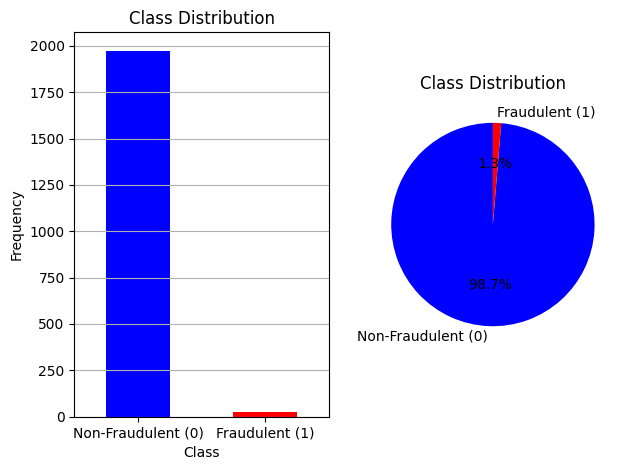

In [ ]:
# Plot the distribution of the 'Class' column as a bar chart
class_distribution=data['Class'].value_counts()
plt.subplot(1, 2, 1)
class_distribution.plot(kind='bar', color=['blue', 'red'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent (0)', 'Fraudulent (1)'], rotation=0)
plt.grid(axis='y')
# Plot the distribution of the 'Class' column as a pie chart
plt.subplot(1, 2, 2)
class_distribution.plot(kind='pie', labels=['Non-Fraudulent (0)', 'Fraudulent (1)'], colors=['blue', 'red'], autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution')
plt.ylabel('')
# Show the plots
plt.tight_layout()
plt.show()

#Apply Machine Learning

In [9]:
#create independent & dependent variables
X=data.drop('Class', axis=1)
y=data['Class']

In [10]:
#scale the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [11]:
#scale the data
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train[['Time','Amount']]=sc.fit_transform(X_train[['Time','Amount']])
X_test[['Time','Amount']]=sc.transform(X_test[['Time','Amount']])

In [13]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1400, 30), (1400,), (600, 30), (600,))

In [14]:
y_train.value_counts()

Class
0    1382
1      18
Name: count, dtype: int64